# $O(n^2)$

## 1. Import các thư viện

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
import os
from utils import plot_execution_times, measure_algorithm_time
import random
import sys
import json

# Cấu hình tham số đồ thị
plt.rcParams['figure.figsize'] = (14, 10)
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Cài đặt thuật toán có độ phức tạp $O(n^2)$

Các thuật toán thuộc nhóm **$O(n^2)$** là những phương pháp sắp xếp cơ bản, thường sử dụng **cấu trúc lặp lồng nhau (nested loops)** để thực hiện việc so sánh và hoán đổi các phần tử trong mảng. Do đó, số lượng phép toán tăng theo bình phương kích thước dữ liệu đầu vào, khiến thời gian thực thi tăng nhanh khi kích thước mảng lớn.

Tuy nhiên, hiệu năng của các thuật toán này **không chỉ phụ thuộc vào kích thước dữ liệu**, mà còn bị ảnh hưởng đáng kể bởi **đặc điểm của dữ liệu đầu vào**. Trong nhiều trường hợp, với dữ liệu nhỏ hoặc gần như đã được sắp xếp, các thuật toán O(n²) vẫn có thể hoạt động hiệu quả.

Các thuật toán tiêu biểu trong nhóm này gồm:

- **Bubble Sort (Sắp xếp nổi bọt):** liên tục so sánh và hoán đổi các phần tử kề nhau.
- **Selection Sort (Sắp xếp chọn):** mỗi bước chọn phần tử nhỏ nhất và đưa về vị trí đúng.
- **Insertion Sort (Sắp xếp chèn):** chèn từng phần tử vào vị trí thích hợp trong phần đã sắp xếp.

Trong phạm vi bài này, chúng tôi lựa chọn hai thuật toán tiêu biểu là:

- **Insertion Sort**
- **Selection Sort**

Việc lựa chọn này nhằm mục đích làm nổi bật **ảnh hưởng của dữ liệu đầu vào đến hiệu năng thuật toán**:

- **Insertion Sort** hoạt động rất hiệu quả với dữ liệu **gần như đã được sắp xếp**, khi đó số phép dịch chuyển giảm đáng kể (gần với O(n)).
- **Selection Sort** có số phép so sánh gần như **không phụ thuộc vào dữ liệu đầu vào**, do luôn duyệt toàn bộ phần chưa sắp xếp để tìm giá trị nhỏ nhất.

Do đó, hai thuật toán này đại diện cho hai trường hợp:
- Một thuật toán **nhạy với cấu trúc dữ liệu** (Insertion Sort)
- Một thuật toán **ít bị ảnh hưởng bởi dữ liệu** (Selection Sort)

### 2.1 Selection Sort

In [2]:
def selection_sort(arr):
    n = len(arr)
    for i in range(n):
        min_idx = i
        for j in range(i + 1, n):
            if arr[j] < arr[min_idx]:
                min_idx = j
        arr[i], arr[min_idx] = arr[min_idx], arr[i]

### 2.2 Insertion Sort

In [3]:
def insertion_sort(arr):
    n = len(arr)
    for i in range(1, n):
        key = arr[i]
        j = i - 1

        while j >= 0 and arr[j] > key:
            arr[j + 1] = arr[j]
            j -= 1

        arr[j + 1] = key

## 3. Đọc dữ liệu từ file npz

In [4]:
sizes = [100, 1000, 10000, 100000]
datasets = ['random', 'nearly_sorted', 'many_duplicates', 'reverse_sorted']
base_path = '../data/' 

# Từ điển lưu trữ dữ liệu đã đọc: cấu trúc loaded_data['tên_dataset']['kích_thước']
loaded_data = {data_type: {} for data_type in datasets}

print("Đang tải dữ liệu lên bộ nhớ...")
for data_type in datasets:
    for size in sizes:
        folder_name = f'n_{size}'
        file_name = f'{data_type}_n{size}.npz'
        file_path = os.path.join(base_path, folder_name, file_name)
        
        try:
            npz_file = np.load(file_path)
            keys = npz_file.files
            # Lưu mảng dữ liệu vào từ điển
            loaded_data[data_type][size] = npz_file[keys[0]]
        except Exception as e:
            print(f"Lỗi với file {file_path}: {e}")
            loaded_data[data_type][size] = None

print("Đã tải xong toàn bộ dữ liệu!")

Đang tải dữ liệu lên bộ nhớ...
Đã tải xong toàn bộ dữ liệu!


## 4. Đo thời gian

### 4.1 Đo với thuật toán Selection Sort

In [5]:
print("Đang đo Selection Sort")
results_selection_sort = measure_algorithm_time(selection_sort, loaded_data, datasets, sizes, num_runs=1)

Đang đo Selection Sort


### 4.2 Đo với thuật toán Insertion Sort

In [6]:
print("Đang đo Insertion Sort")
results_insertion_sort = measure_algorithm_time(insertion_sort, loaded_data, datasets, sizes, num_runs=1)

Đang đo Insertion Sort


## 5. Biểu đồ trực quan

### 5.1 Selection Sort

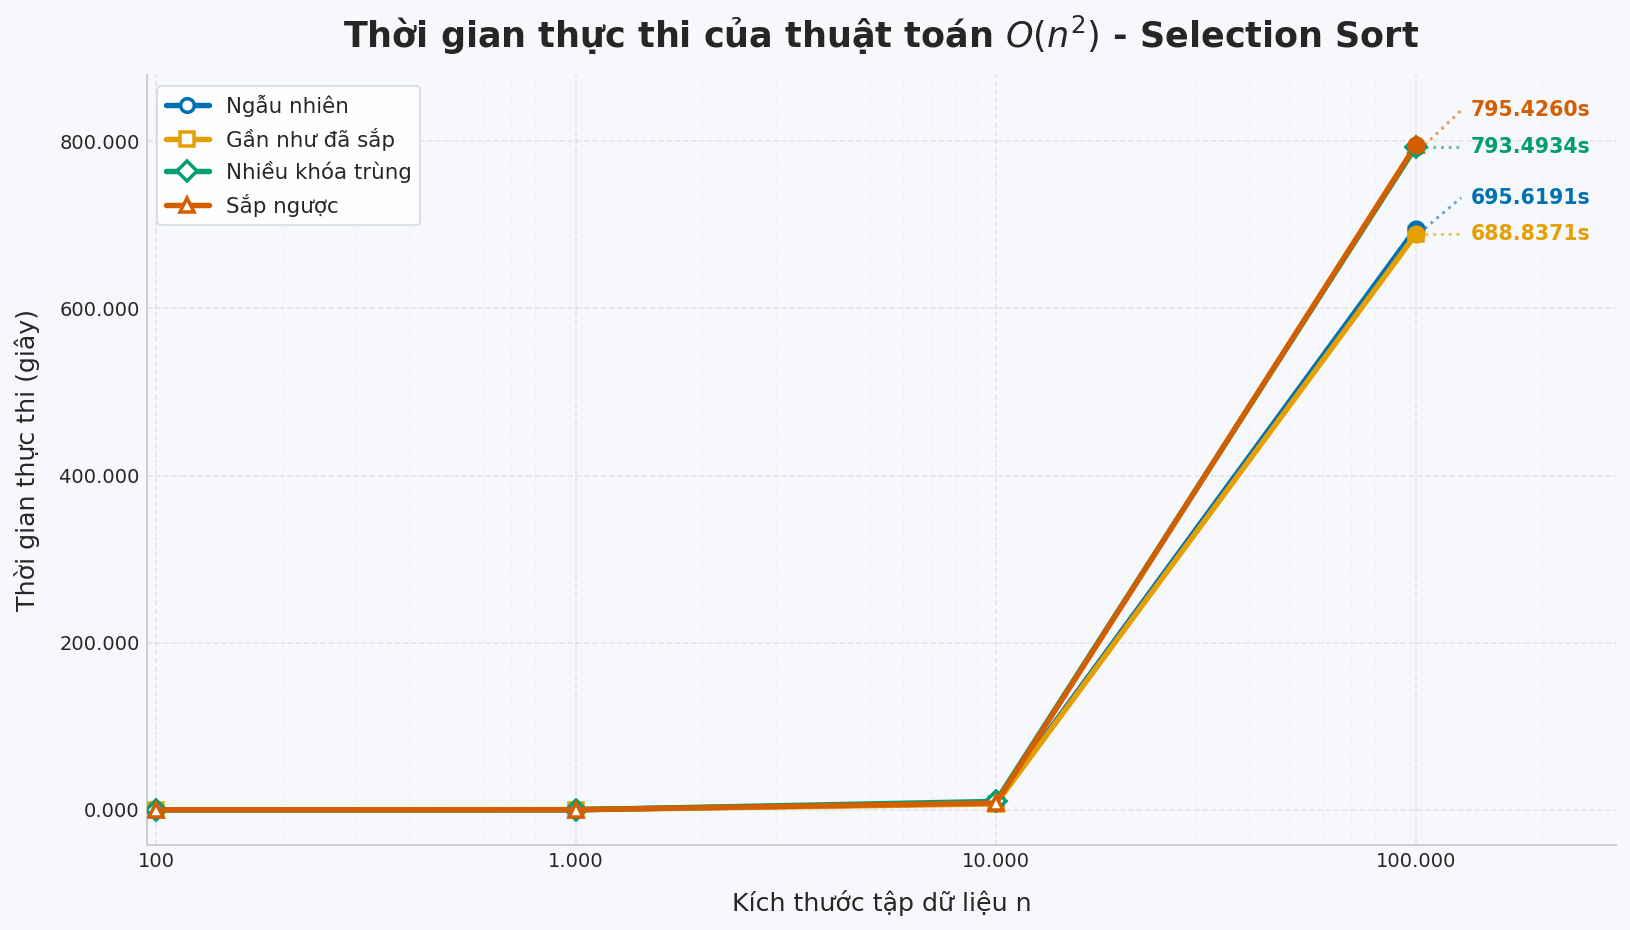

In [7]:
plot_execution_times(
    results_dict=results_selection_sort, 
    sizes=sizes, 
    datasets=datasets, 
    algo_name="$O(n^2)$ - Selection Sort"
)


### 5.2 Insertion Sort

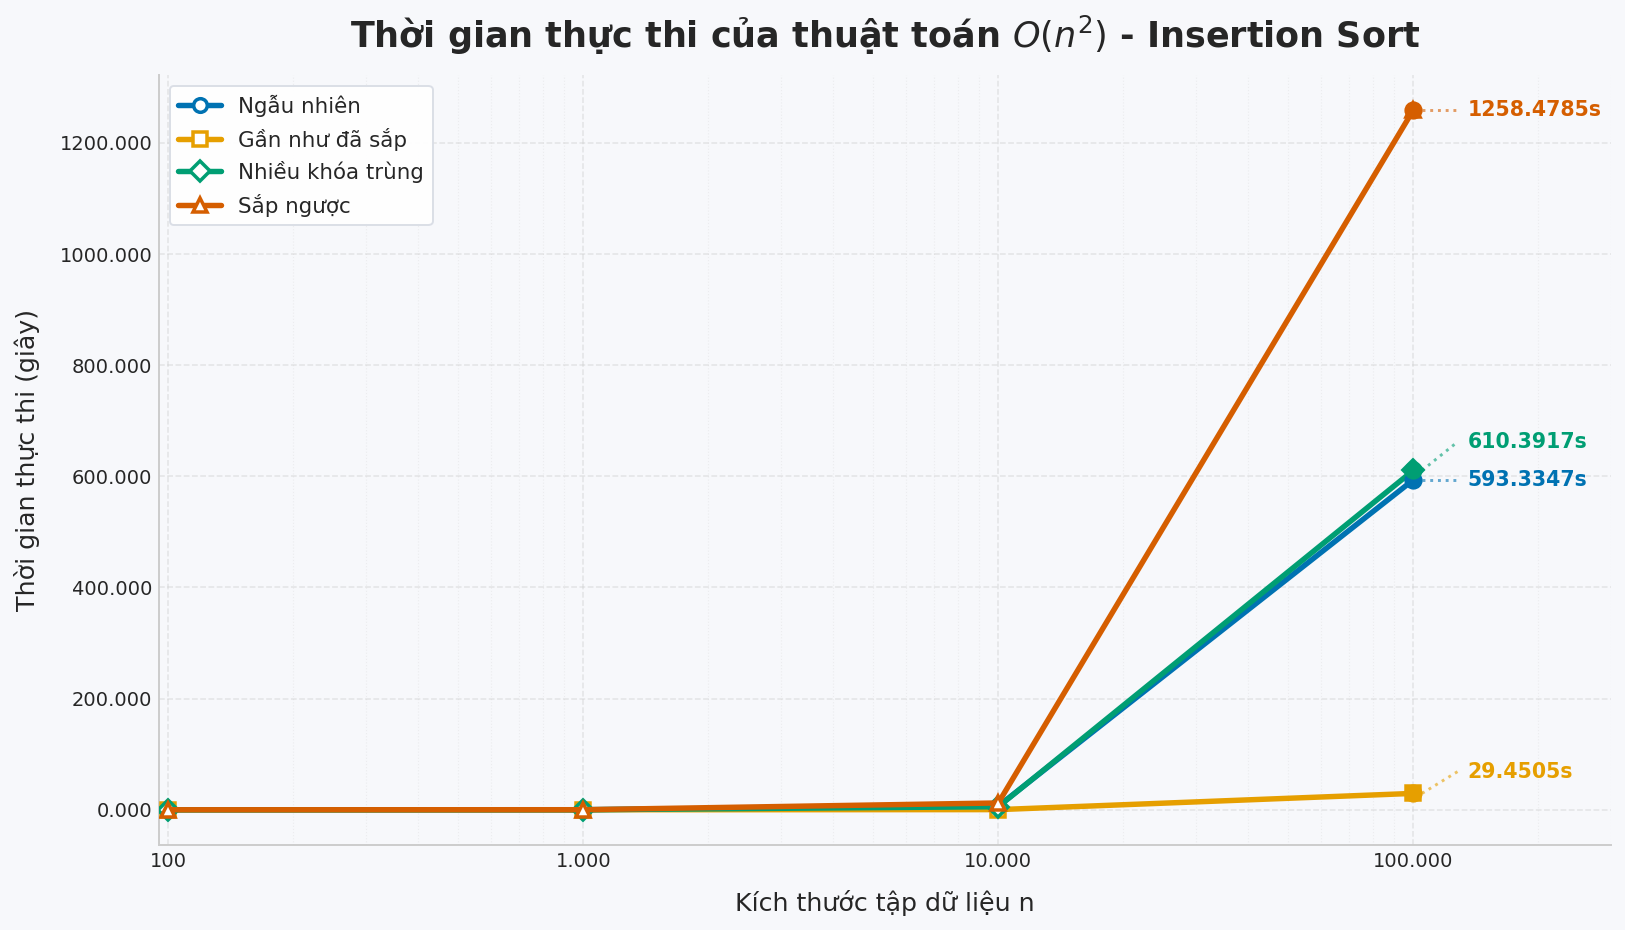

In [8]:
plot_execution_times(
    results_dict=results_insertion_sort, 
    sizes=sizes, 
    datasets=datasets, 
    algo_name="$O(n^2)$ - Insertion Sort"
)

In [9]:
os.makedirs("results", exist_ok=True)

with open("results/selection_sort.json", "w") as f:
    json.dump(results_selection_sort, f)

with open("results/insertion_sort.json", "w") as f:
    json.dump(results_insertion_sort, f)
    
print("Đã lưu kết quả O(n^2) thành công!")

Đã lưu kết quả O(n^2) thành công!
